In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import os

In [5]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers


In [40]:
from tensorflow.keras.layers import Conv2D
from tensorflow.keras import Input
import numpy as np

In [6]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 10

In [7]:
# Importing image dataset from a directory using TensorFlow
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "leaf/data",
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)






Found 4188 files belonging to 4 classes.


In [8]:
class_name  = dataset.class_names
class_name

['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']

In [80]:
leaf = {1 : 'Blight', 2 : 'Common_Rust', 3 : 'Gray_leaf_spot', 4 : 'Healthy'}
leaf.get(3)

'Gray_leaf_spot'

In [81]:
leaf.values()

dict_values(['Blight', 'Common_Rust', 'Gray_leaf_spot', 'Healthy'])

In [82]:
leaf.items()

dict_items([(1, 'Blight'), (2, 'Common_Rust'), (3, 'Gray_leaf_spot'), (4, 'Healthy')])

In [83]:
list_leaf = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
list_leaf.sort(key = len)
list_leaf

['Blight', 'Healthy', 'Common_Rust', 'Gray_Leaf_Spot']

In [86]:
matrix = [['Blight'], ['Common_Rust'], ['Gray_Leaf_Spot'], ['Healthy']]
print(matrix)

[['Blight'], ['Common_Rust'], ['Gray_Leaf_Spot'], ['Healthy']]


In [87]:
print(matrix[2])

['Gray_Leaf_Spot']


In [88]:
matrix = [['Blight'], ['Common_Rust'], ['Gray_Leaf_Spot'], ['Healthy']]
for row in matrix:
    for value in row:
        print(value, end=' ')
        
        print()


Blight 
Common_Rust 
Gray_Leaf_Spot 
Healthy 


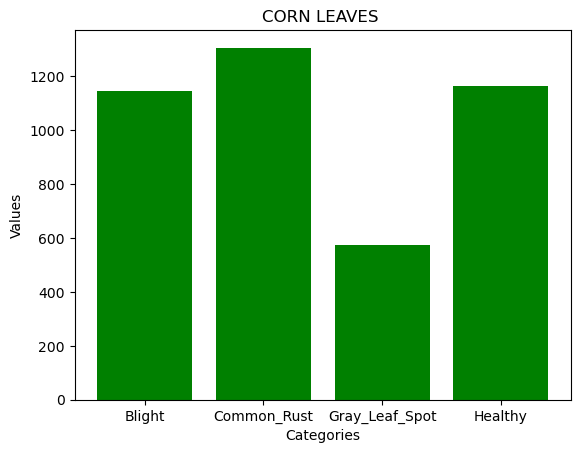

In [14]:
# Data for the bar graph
categories = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
values = [1146, 1306, 574, 1162]

# Create a bar graph
plt.bar(categories, values ,color = 'green' , width = 0.8)

# Add titles and labels
plt.title('CORN LEAVES ')

plt.xlabel('Categories')

plt.ylabel('Values')

# Show the plot
plt.show()

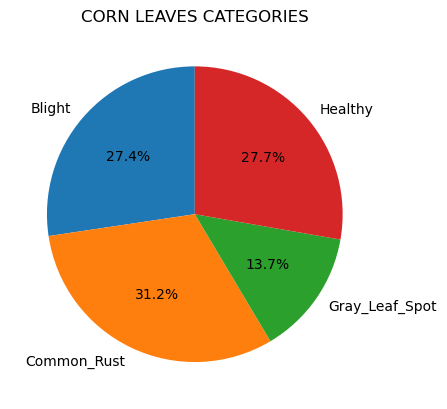

In [15]:
# Data for the pie chart
labels = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
sizes = [1146, 1306, 574, 1162]

# Create the pie chart
plt.pie(sizes, labels=labels, autopct='%1.1f%%' , startangle = 90)

# Display the chart
plt.title('CORN LEAVES CATEGORIES')
plt.show()

(32, 256, 256, 3)
[2 1 0 0 0 0 1 3 1 0 3 0 1 3 0 0 3 2 3 3 2 3 0 0 0 1 0 1 2 0 3 1]


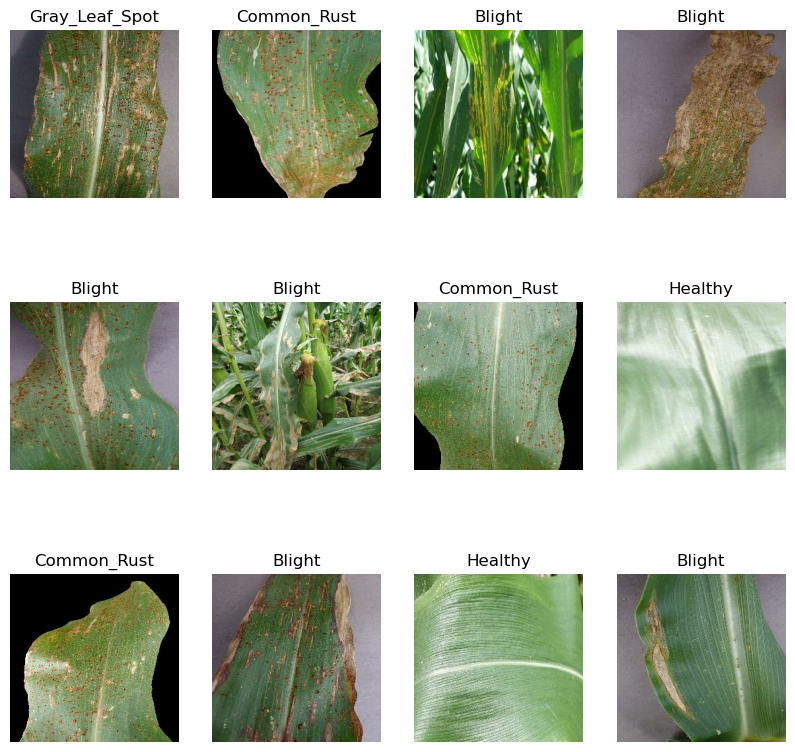

In [20]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):

    print(image_batch.shape)
    print(label_batch.numpy())
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")


segnmentations

In [10]:
len(dataset)

131

In [23]:
131*32

4192

80% training 
20 %  =  10% validation -> 10% actual testing 

In [12]:
train_size = 0.8
len(dataset)*train_size

104.80000000000001

In [13]:
104*32

3328

In [25]:
train_ds = dataset.take(104)
len(train_ds)

104

In [26]:
test_ds = dataset.skip(104)
len(test_ds)

27

In [11]:
27*32

864

In [27]:
val_size = 0.1
len(dataset)*val_size

13.100000000000001

In [28]:
val_ds = test_ds.take(13)
len(val_ds)


13

In [29]:
test_ds = test_ds.skip(13)
len(test_ds)

14

In [30]:
def get_dataset_partitions_tf(ds, train_split=0.8 , val_split=0.1 ,test_split=0.1 ,shuffle=True, shuffle_size=10000):
    assert(train_split + val_split + test_split) == 1
    ds_size = len(ds)
    if shuffle:
        
        ds = ds.shuffle(shuffle_size, seed = 12)
        



    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds  = ds.skip(train_size).skip(val_size)

    
    return train_ds, val_ds, test_ds
    
    
        


In [31]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(Rocks)

In [32]:
len(train_ds)

104

In [33]:
len(test_ds)

14

In [34]:
len(val_ds)

13

 Retain in Memory that Help to Fetch as Prompt

In [35]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds= test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

 Converting into Numpy Array and Normalizes the Pixel Values

In [91]:
for image_batch , label_batch in dataset.take(1):
    print(image_batch[0].numpy()/255)

[[[0.         0.02352941 0.00784314]
  [0.         0.02745098 0.00784314]
  [0.02745098 0.03529412 0.01568628]
  ...
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]]

 [[0.         0.01960784 0.00784314]
  [0.         0.03921569 0.02352941]
  [0.         0.00392157 0.        ]
  ...
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]]

 [[0.         0.01960784 0.        ]
  [0.         0.02352941 0.        ]
  [0.         0.00784314 0.        ]
  ...
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]]

 ...

 [[0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  ...
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]]

 [[0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]


Data Augnmentation

In [37]:

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

Building a Model 

In [41]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 4

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size=(3,3), activation="relu",input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation = "softmax"),
    
])
    

In [42]:
model.build(input_shape=input_shape)

In [43]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 4)                │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,812 (718.02 KB)

 Trainable params: 183,812 (718.02 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)


Let's Train Model

In [45]:
history = model.fit(
    train_ds,
    batch_size = BATCH_SIZE,
    validation_data = val_ds,
    verbose=1,
    epochs = EPOCHS
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.5435 - loss: 0.9955 - val_accuracy: 0.8221 - val_loss: 0.4330
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8019 - loss: 0.5050 - val_accuracy: 0.8486 - val_loss: 0.3825
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8376 - loss: 0.3990 - val_accuracy: 0.8221 - val_loss: 0.4297
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8441 - loss: 0.3699 - val_accuracy: 0.7981 - val_loss: 0.4852
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8387 - loss: 0.4027 - val_accuracy: 0.8534 - val_loss: 0.3412
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8526 - loss: 0.3591 - val_accuracy: 0.8630 - val_loss: 0.3382
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8618 - loss: 0.3237 - val_accuracy: 0.8630 - val_loss: 0.3305
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8623 - loss: 0.3179 - val_accu

In [46]:
len(test_ds)

14

In [47]:
scores = model.evaluate(test_ds)

14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 397ms/step - accuracy: 0.9118 - loss: 0.2734


In [48]:
scores

[0.2995922863483429, 0.90625]

In [49]:
history.params

{'verbose': 1, 'epochs': 10, 'steps': 104}

In [50]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [51]:
history.history["loss"]

[0.7051036357879639,
 0.466286301612854,
 0.4178659915924072,
 0.3988598883152008,
 0.3931921422481537,
 0.3550179600715637,
 0.33016952872276306,
 0.3389008939266205,
 0.3137889802455902,
 0.30077624320983887]

In [52]:
history.history["accuracy"]

[0.7021660804748535,
 0.8131768703460693,
 0.8318291306495667,
 0.833935022354126,
 0.8345367312431335,
 0.854091465473175,
 0.861311674118042,
 0.8570998907089233,
 0.8685318827629089,
 0.8751504421234131]

In [53]:
len(history.history["loss"])

10

Learning Curves

In [54]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

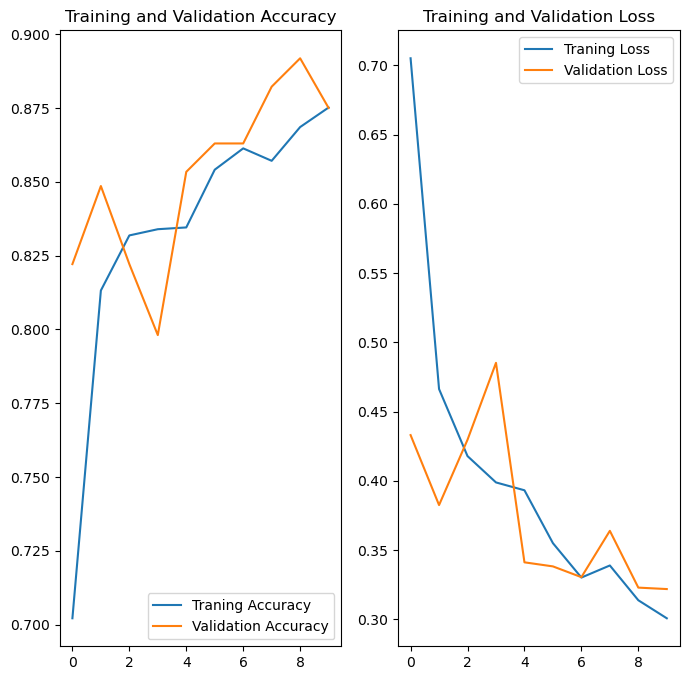

In [55]:
plt.figure(figsize=(8,8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc , label= "Traning Accuracy")
plt.plot(range(EPOCHS), val_acc, label = "Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss , label= "Traning Loss")
plt.plot(range(EPOCHS), val_loss, label = "Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

First Image is Predicting from Batch 

First Image To Predict 
Label: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step
[4.0336207e-01 1.8255678e-01 4.1404226e-01 3.8942508e-05]


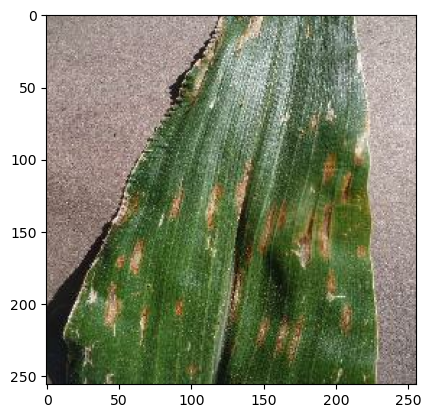

In [56]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    print("First Image To Predict ")
    plt.imshow(first_image)
    print("Label:",label_batch[0].numpy())
    batch_prediction = model.predict(image_batch)
    print(batch_prediction[0])

First Image To Predict 
Actual Label: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
Predicted Label : 1


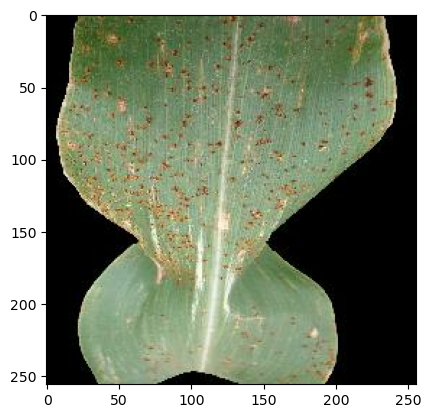

In [57]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    print("First Image To Predict ")
    plt.imshow(first_image)
    print("Actual Label:",label_batch[0].numpy())
    batch_prediction = model.predict(image_batch)
    print("Predicted Label :",np.argmax(batch_prediction[0]))

First Image To Predict 
Actual Label: Healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
Predicted Label : Healthy


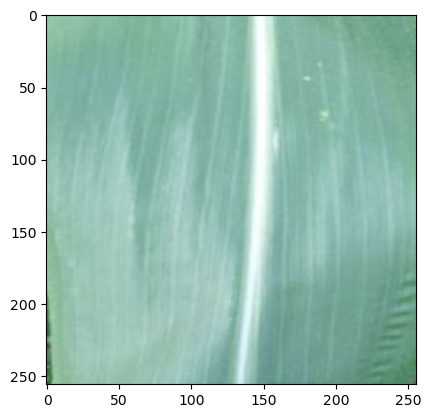

In [58]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    print("First Image To Predict ")
    plt.imshow(first_image)
    print("Actual Label:",class_names[label_batch[0].numpy()])
    batch_prediction = model.predict(image_batch)
    print("Predicted Label :",class_names[np.argmax(batch_prediction[0])])

🔍 Prediction Function:

In [59]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100*(np.max(predictions[0])),2)
    return predicted_class, confidence


📊 Visualization:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


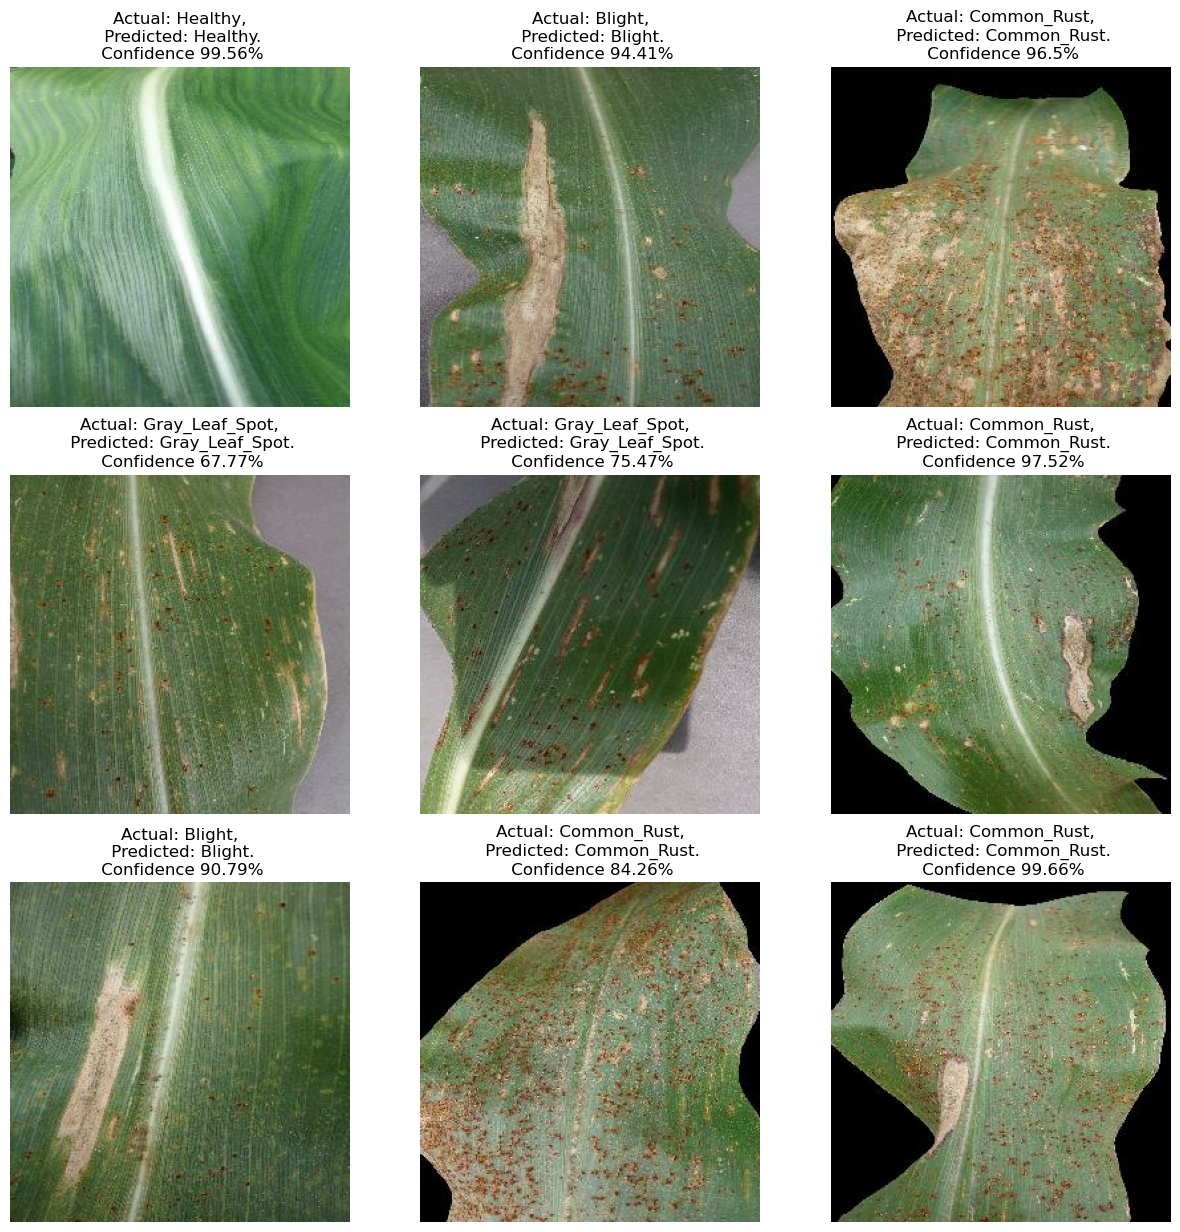

In [60]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3 , i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence  = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence {confidence}%")
        plt.axis("off")

In [74]:
model.save("corn.keras")